**ICD/FDS**

Decision Trees


Let's use our favorite dataset again 🥰

We will play with this dataset and change some learning parameters.

You can vary: tree depth, minimum number of instances per leaf, `cc_alpha` etc (please, check the [Python doc on DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) to know which parameters to change).

Use model validation (train-test percentage split, cross-validation or bootstrapping) to find a better model.

As this dataset has a good number of plantes of each species (**balanced classes**) and very good discriminatory features, you may not see a big difference among the models.

Repeat the same experiments using any dataset of the [UCI repository](https://archive.ics.uci.edu/datasets/) and compare the results found with models. The dataset chosen needs to be suitable for a **supervised classification** learning task.

In [18]:
import pandas as pd

iris = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv')
feature_names = iris.columns[0:4]
class_names = iris['species'].unique()
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
import numpy as np
X=iris.iloc[:,0:4]
y=np.array(iris['species'])
X,y

(     sepal_length  sepal_width  petal_length  petal_width
 0             5.1          3.5           1.4          0.2
 1             4.9          3.0           1.4          0.2
 2             4.7          3.2           1.3          0.2
 3             4.6          3.1           1.5          0.2
 4             5.0          3.6           1.4          0.2
 ..            ...          ...           ...          ...
 145           6.7          3.0           5.2          2.3
 146           6.3          2.5           5.0          1.9
 147           6.5          3.0           5.2          2.0
 148           6.2          3.4           5.4          2.3
 149           5.9          3.0           5.1          1.8
 
 [150 rows x 4 columns],
 array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
        'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
        'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
        'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'se

In [3]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=0)
model.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [4]:
preds = model.predict(X)
(vals,ans)=np.unique(preds==y, return_counts=True)
ans[vals]/sum(ans)

array([1.])

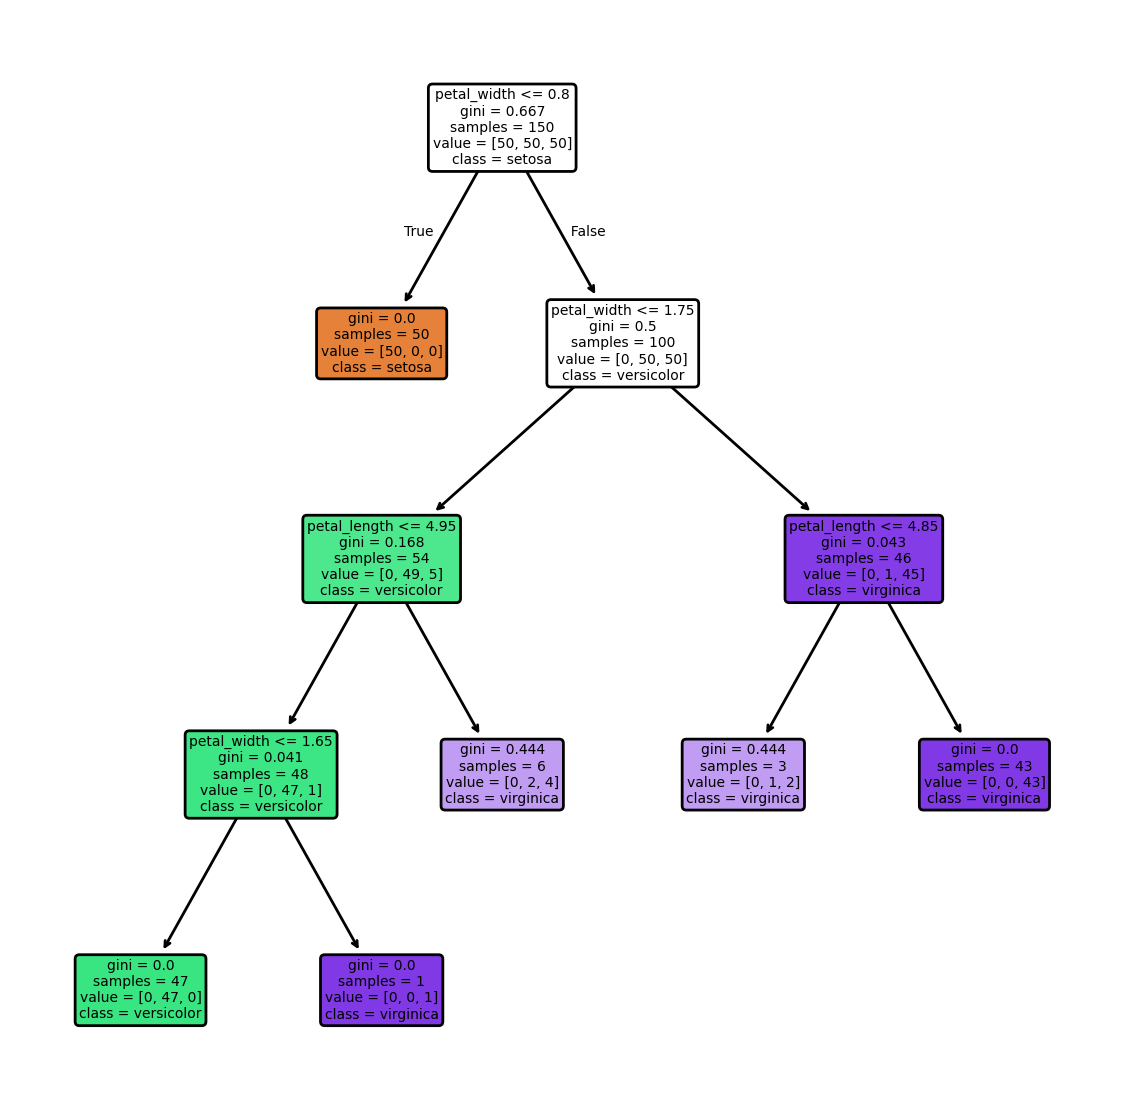

In [21]:
from sklearn import tree
from matplotlib import pyplot as plt

def plottree(model):
    plt.subplots(nrows = 1,ncols = 1,figsize = (7,7), dpi=200)
    tree.plot_tree(model, feature_names=feature_names,class_names=class_names,rounded=True, fontsize=5, filled=True)
    plt.show()

plottree(model)

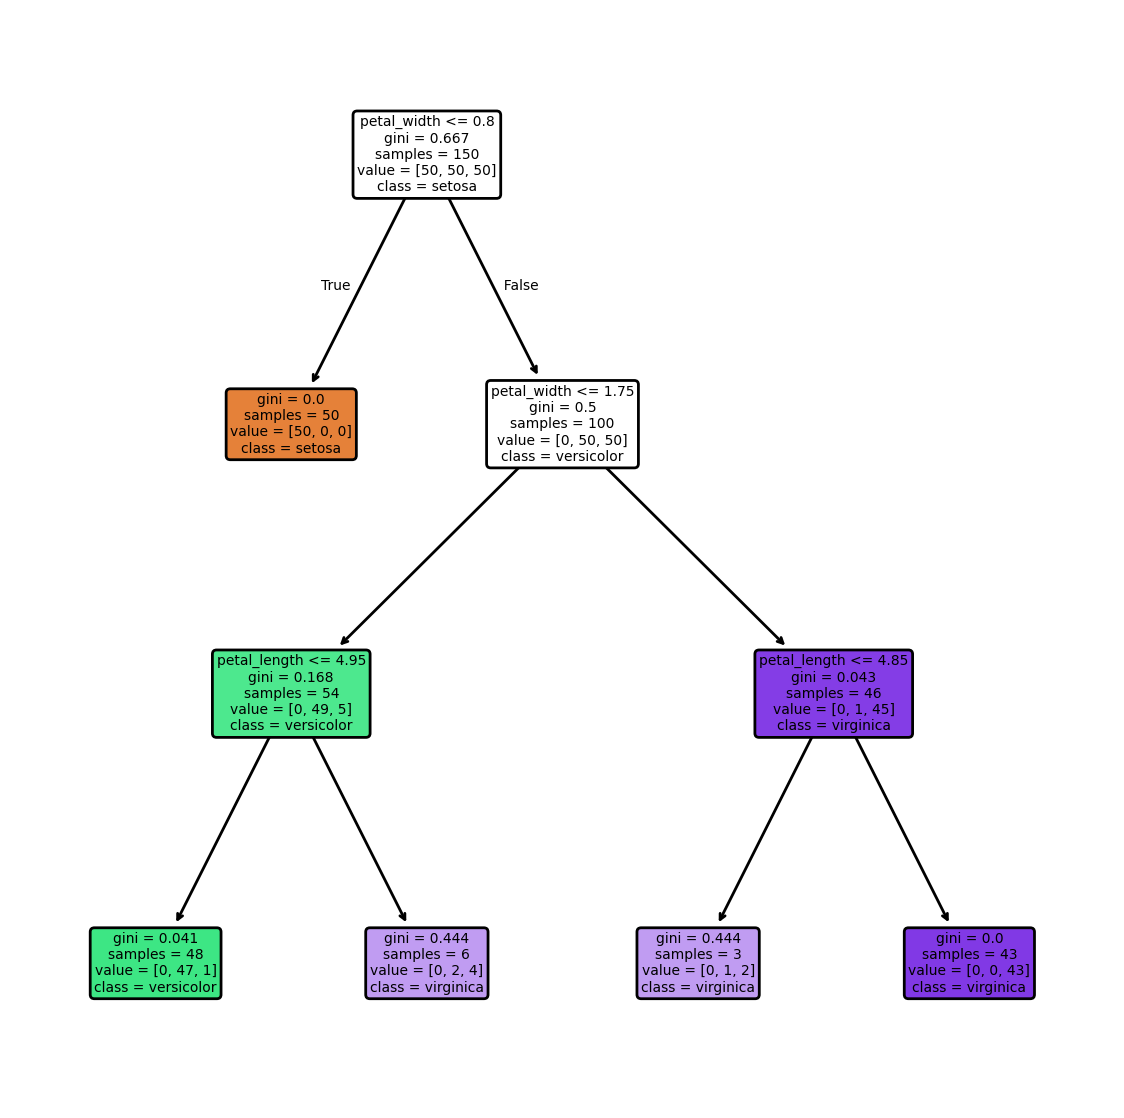

In [22]:
model = DecisionTreeClassifier(random_state=0,max_depth=3)
model.fit(X,y)

plottree(model)

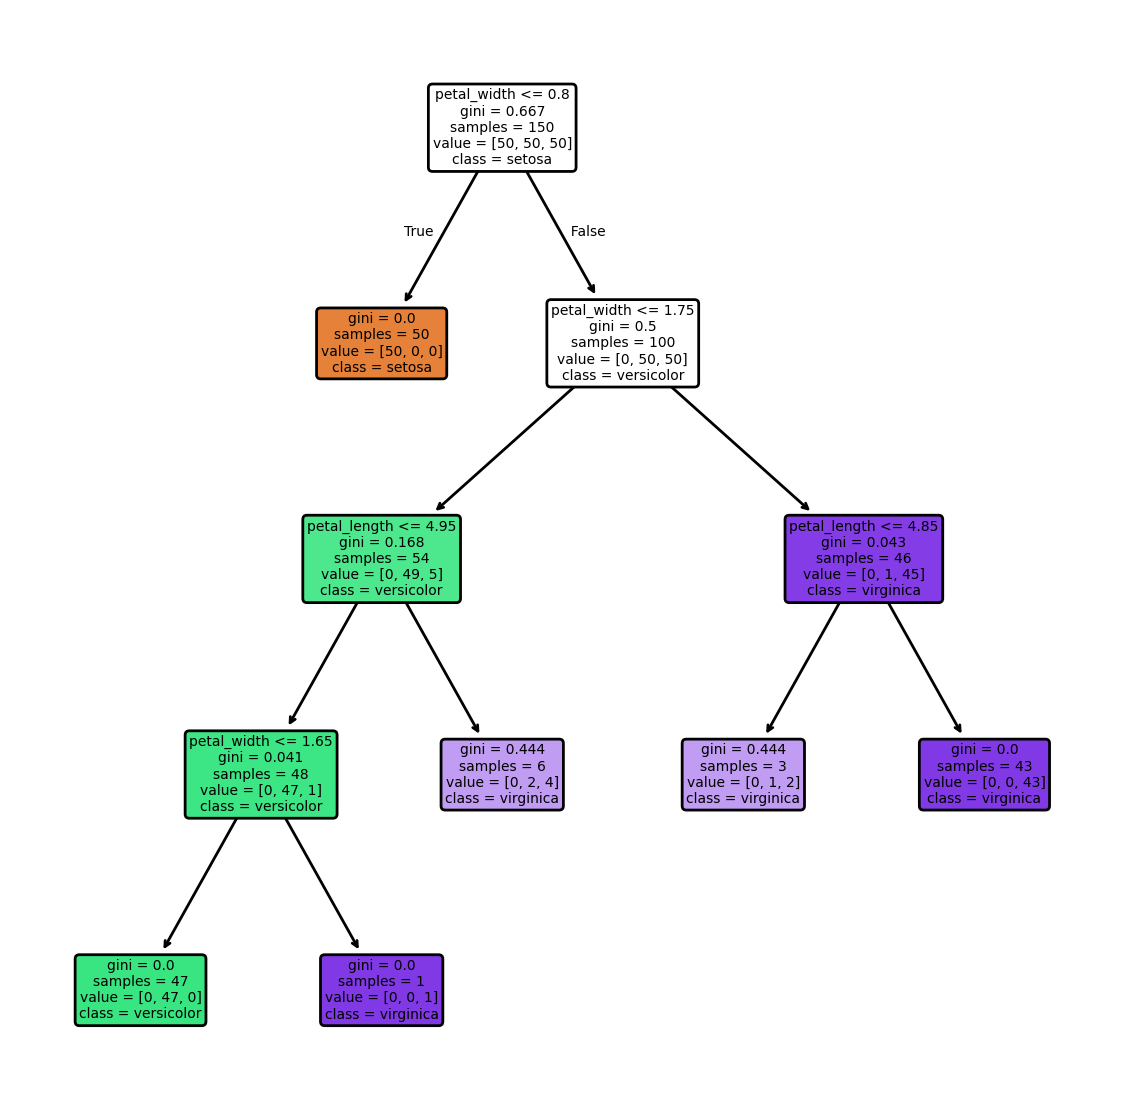

In [23]:
model = DecisionTreeClassifier(random_state=0,min_samples_split=20) # alt. min_samples_leaf
model.fit(X,y)

plottree(model)

## Sumario Medidas de Impureza 

| Valor da Medida (Gini, Entropia, Erro) | Significado Prático |
| :--- | :--- |
| **Baixo** ($\approx 0$) | O nó é **Puro** (ou **Homogéneo**). A divisão foi eficaz; a maioria dos dados pertence à mesma classe. |
| **Alto** (Máximo) | O nó é **Impuro** (ou **Heterogéneo**). A divisão foi ineficaz; as classes estão misturadas de forma quase uniforme. |

## Comparacao entre Medidas de Impureza

| Característica | **Gini Index** | **Entropy**| **Missclassification Error** |
| :--- | :--- | :--- | :--- |
| **Fórmula Matemática** | $1 - \sum p_i^2$ | $-\sum p_i \log_2(p_i)$ | $1 - \max(p_i)$ |
| **Intervalo (Binário)** | $0$ a $0.5$ | $0$ a $1$ | $0$ a $0.5$ |
| **Custo Computacional** | **Baixo**. Apenas somas e quadrados. É mais rápido. | **Médio/Alto**. Exige cálculo de logaritmos. | **Muito Baixo**. Apenas comparações. |
| **Sensibilidade** | Tende a isolar a classe mais frequente. | Tende a criar árvores mais equilibradas. | **Pouco sensível**. Raramente usado para gerar a árvore ("splitting"). |
| **Uso Comum** | Padrão no algoritmo CART. | Padrão nos algoritmos ID3 e C4.5. | Usado principalmente na fase de poda (pruning). |

# Cost Complexity pruning

Minimal cost-complexity pruning is an algorithm used to prune a tree to avoid over-fitting. The `ccp_alpha` hyperparameter controls pruning. If $\alpha = 0$
there is no pruning. Higher values for $\alpha$ means more pruning.

The **cost complexity** of a tree $T$ is given by:
$R_\alpha(T) = R(T)+\alpha|\tilde{T}|$

Where $R(T)$ is the error of the tree (misclassification in the leaves) and $|\tilde{T}|$ is the size of the tree (complexity=number of leaves).

Minimal cost-complexity pruning finds the subtree of T
that minimizes $R_\alpha(T)$.

After the tree is fully grown, the algorithm considers the cost complexity of each node $t$, i.e. $R_\alpha(t)=R(t)+\alpha$, where $R(t)$ is the error of the subtree with root $t$.

$R_\alpha(T)$ tends to be smaller than $R_\alpha(t)$. However, as the tree gets to the extremities it is harder to improve $R_\alpha(t)$.

The effective $\alpha_{\text{eff}}$ for each $t$ is the one that makes $R_\alpha(T) = R_\alpha(t)$.

The node with the smallest $\alpha_{\text{eff}}$ is pruned (loses its subtree), but only if it is smaller or equal to `ccp_alpha`.

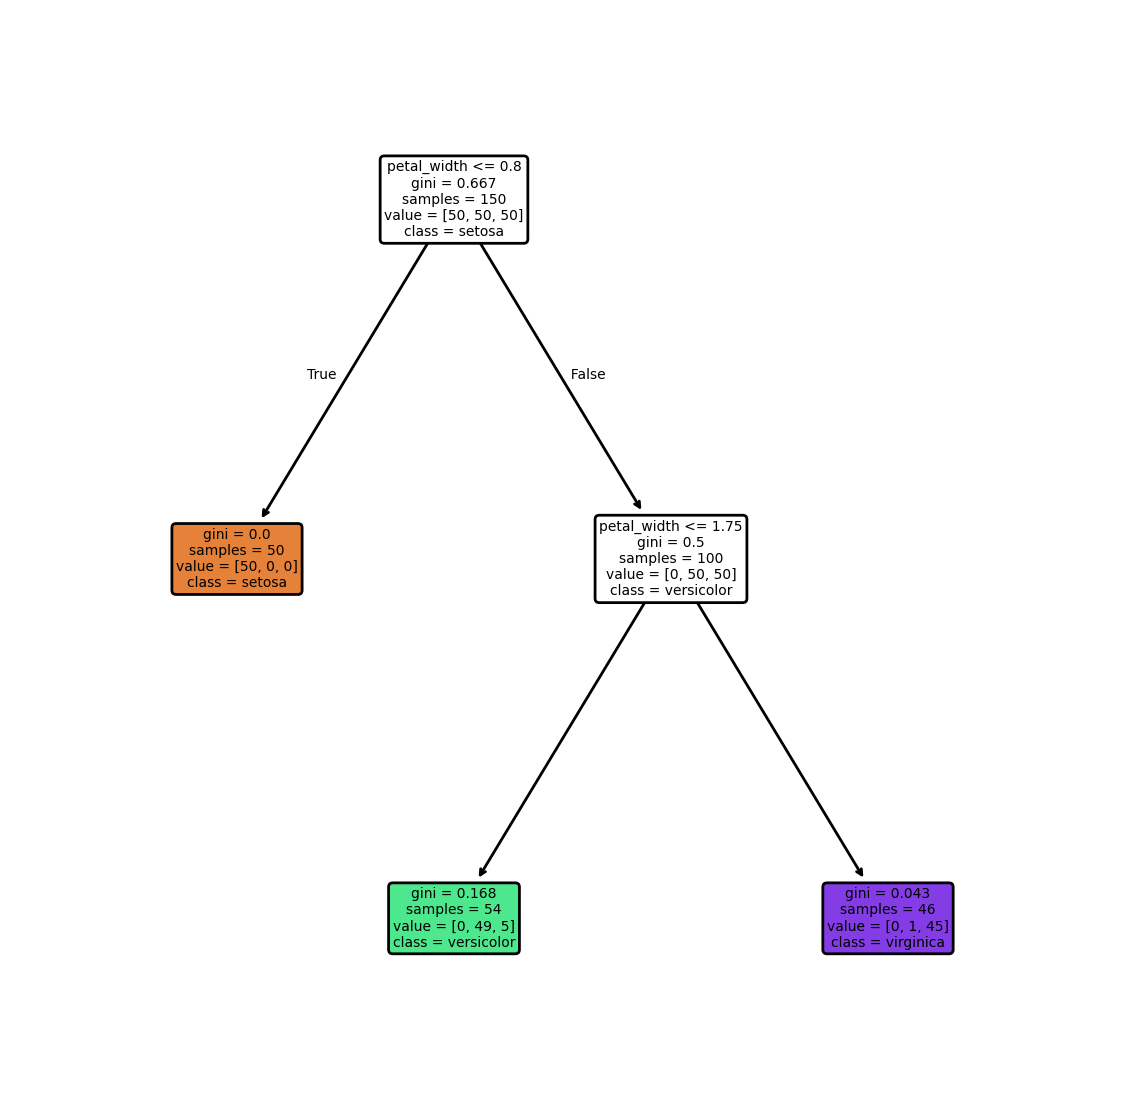

In [27]:
model = DecisionTreeClassifier(random_state=0,ccp_alpha=0.1)
model.fit(X,y)

plottree(model)

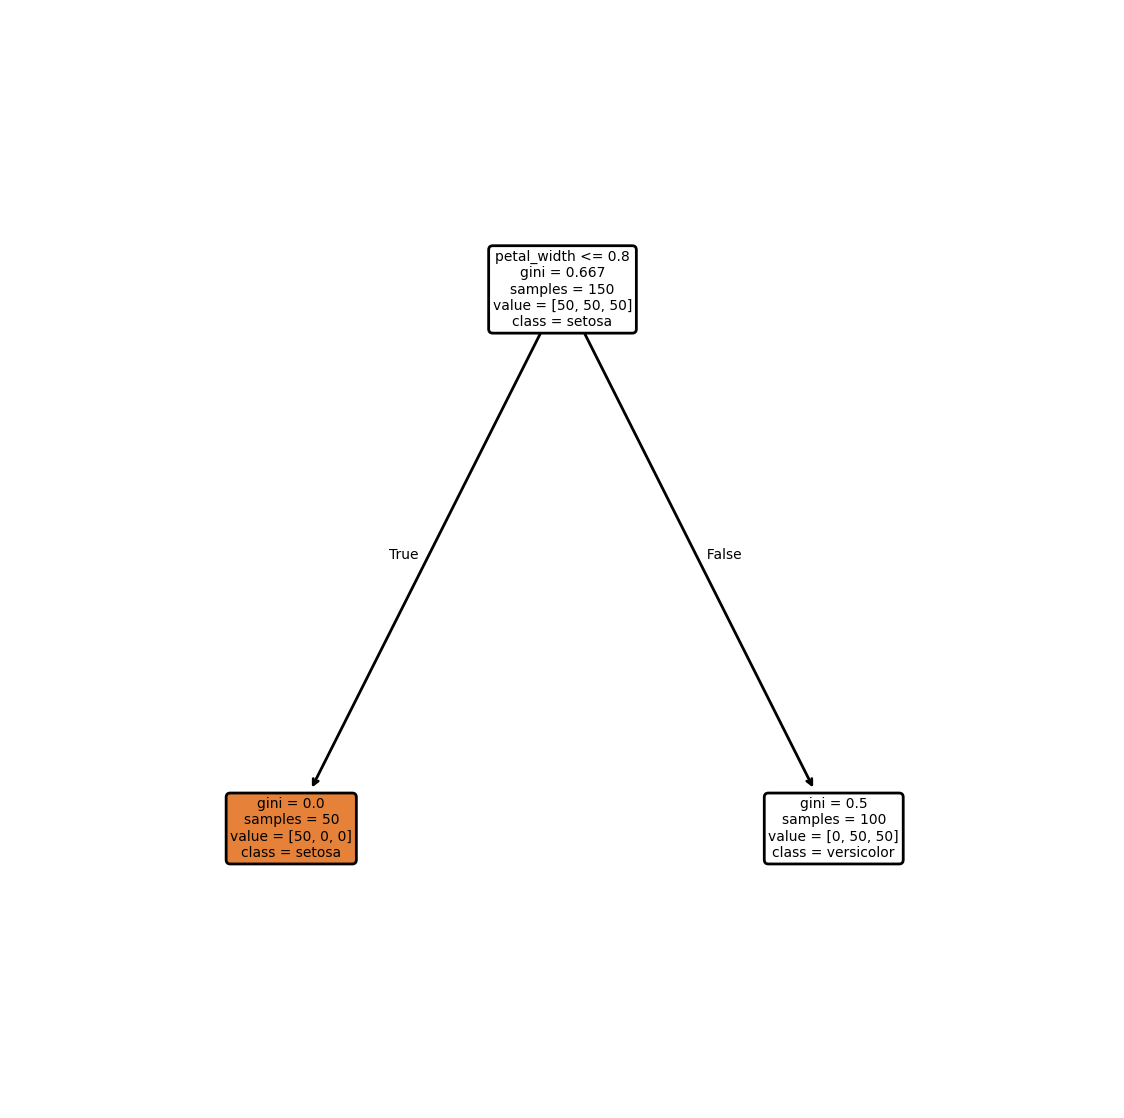

In [30]:
model = DecisionTreeClassifier(random_state=0,ccp_alpha=0.3)
model.fit(X,y)

plottree(model)

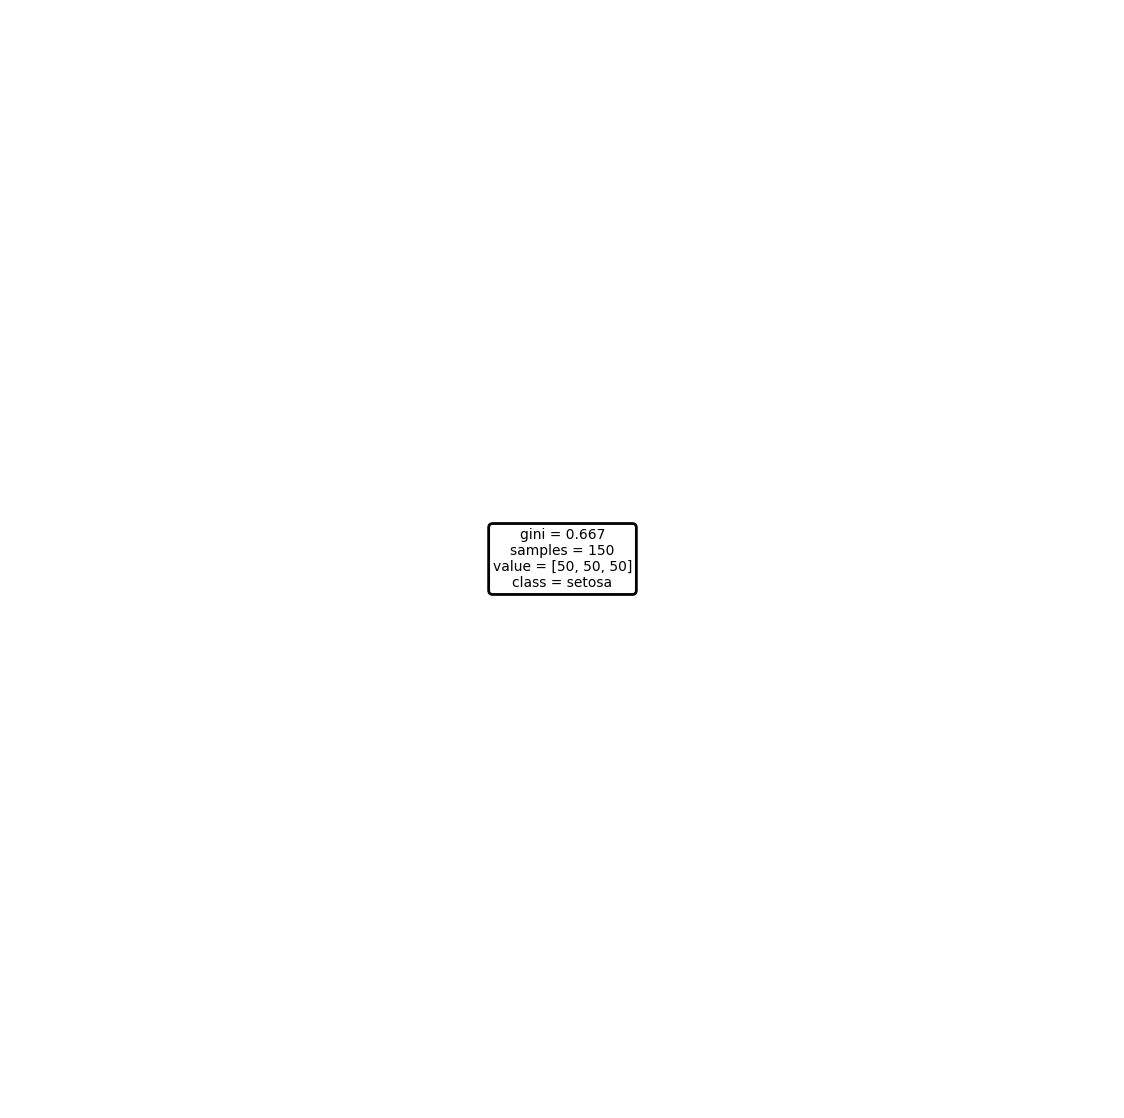

In [28]:
model = DecisionTreeClassifier(random_state=0,ccp_alpha=1)
model.fit(X,y)

plottree(model)



O $\alpha_{\text{eff}}$ mede o "custo" em erro para simplificar a árvore. Ele indica quanto o erro da árvore aumenta por cada folha que removemos ao podar um ramo.

A fórmula base é:
$\alpha_{\text{eff}} = \frac{R(t) - R(T_t)}{|T_t| - 1}$

| Componente | Símbolo | Significado Prático | Interpretação no Cálculo |
| :--- | :---: | :--- | :--- |
| **Erro do Nó Sozinho** | $R(t)$ | O erro que teríamos se cortássemos tudo e deixássemos apenas este nó como uma folha. | Geralmente é **alto**, pois um único nó é um modelo muito simples. |
| **Erro da Subárvore** | $R(T_t)$ | O erro atual da subárvore completa que parte deste nó (com todas as suas ramificações). | Geralmente é **baixo**, pois a subárvore é complexa e ajusta-se bem aos dados. |
| **Melhoria do Erro** | $R(t) - R(T_t)$ | O benefício que a subárvore está a trazer. Quanto erro ela está a corrigir? | Se este valor for **baixo**, a subárvore não está a ajudar muito. |
| **Complexidade** | $\|T_t\| - 1$ | O número de folhas extra que a subárvore adiciona em comparação com o nó sozinho. | Representa o "custo" em complexidade para manter a subárvore. |
| **Alfa Efetivo** | $\alpha_{\text{eff}}$ | **A relação Custo-Benefício**. | Um valor **baixo** significa que a subárvore é "cara" (muita complexidade) para o pouco benefício (pouca redução de erro) que traz. **Estes ramos são os primeiros a serem podados.** |

| Valor de $\alpha_{\text{eff}}$ do Nó | O que significa este Ramo? | Relação com `ccp_alpha` | Impacto na Árvore Final (DT) |
| :--- | :--- | :--- | :--- |
| **Muito Baixo** ($\approx 0$) | **Ruído / Overfitting.** A subárvore adiciona complexidade (nós) mas reduz muito pouco o erro. Provavelmente está a decorar dados irrelevantes. | Geralmente **menor** que o `ccp_alpha`. | **O ramo é cortado.** A árvore torna-se mais simples e generalista, melhorando a performance em dados novos (teste). |
| **Médio / Baixo** | **Detalhe Menor.** Captura padrões subtis que podem ou não ser importantes, dependendo da rigidez que desejas no modelo. | Zona de decisão. Se for **$\le$** `ccp_alpha`, é cortado. | Define o equilíbrio entre Viés e Variância. Se cortado, evita *overfitting*; se mantido, captura mais nuances. |
| **Alto** | **Padrão Forte.** A subárvore reduz drasticamente o erro (ex: separa claramente duas classes distintas). É essencial para o modelo. | Geralmente **maior** que o `ccp_alpha`. | **O ramo é mantido.** A árvore preserva esta estrutura para garantir uma boa precisão base (acurácia). |
| **Máximo** (Geralmente na Raiz) | **Divisão Fundamental.** É a característica mais importante do dataset, que melhor separa os dados iniciais. | Muito superior a qualquer `ccp_alpha` razoável. | **Base da Árvore.** Se este nó fosse podado, o modelo tornar-se-ia apenas um "chute" da média ou da moda (apenas a raiz). |